# Phase 2: Visual Closed-Loop Control

This notebook closes the loop by using NeuroKin-3D visual estimates to drive a Jacobian-based IK controller in PyBullet.

In [1]:
import os
import sys
import time
import random
import importlib.util
import numpy as np
import matplotlib.pyplot as plt


def ensure_package(module_name, pip_name=None):
    if importlib.util.find_spec(module_name) is None:
        import subprocess
        package_name = pip_name or module_name
        if module_name == 'pybullet' and os.name == 'nt' and sys.version_info >= (3, 12):
            raise RuntimeError(
                'pybullet has no reliable prebuilt wheel for this Windows/Python 3.12 runtime. '
                'Run this notebook in Colab or a Python 3.10/3.11 environment, or install Microsoft C++ Build Tools.'
            )
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', package_name])
        except subprocess.CalledProcessError as exc:
            raise RuntimeError(
                f'Could not install {package_name}. If this is pybullet on Windows/Python 3.12, '
                'use Python 3.10/3.11, Colab, or install Microsoft C++ Build Tools.'
            ) from exc


for module_name, pip_name in [('pybullet', 'pybullet'), ('cv2', 'opencv-python'), ('torch', 'torch')]:
    ensure_package(module_name, pip_name)

import pybullet as p
import pybullet_data
import cv2
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


def find_project_root():
    candidates = [
        os.environ.get('ROBOT_SELF_MODELLING_ROOT'),
        '/content/drive/MyDrive/robot_self_modelling',
        '/content/robot_self_modelling',
        os.path.expanduser('~/robot_self_modelling'),
        os.path.join(os.path.expanduser('~'), 'Downloads', 'robot_self_modelling'),
        os.path.abspath('.'),
        os.path.abspath('..'),
    ]
    checked = []
    for root in candidates:
        if not root:
            continue
        root = os.path.abspath(os.path.expanduser(root))
        if root in checked:
            continue
        checked.append(root)
        urdf_candidate = os.path.join(root, 'RobotArmURDF', '4dof_1st', 'urdf', '4dof_1st.urdf')
        if os.path.exists(urdf_candidate):
            return root, checked
    return os.path.abspath('.'), checked


ROOT_DIR, ROOT_SEARCH_PATHS = find_project_root()
URDF_PATH = os.path.join(ROOT_DIR, 'RobotArmURDF', '4dof_1st', 'urdf', '4dof_1st.urdf')
MODEL_PATH = os.path.join(ROOT_DIR, 'models', 'neurokin_3d_best.pth')
print(f'ROOT_DIR: {ROOT_DIR}')
print(f'URDF_PATH: {URDF_PATH}')
print(f'MODEL_PATH: {MODEL_PATH}')


Mounted at /content/drive
ROOT_DIR: /content/drive/MyDrive/robot_self_modelling
URDF_PATH: /content/drive/MyDrive/robot_self_modelling/RobotArmURDF/4dof_1st/urdf/4dof_1st.urdf
MODEL_PATH: /content/drive/MyDrive/robot_self_modelling/models/neurokin_3d_best.pth


In [2]:
import os
import sys
import time
import random
import importlib.util
import numpy as np
import matplotlib.pyplot as plt

def ensure_package(pkg):
    if importlib.util.find_spec(pkg) is None:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', pkg])

for pkg in ['pybullet', 'opencv-python', 'torch']:
    ensure_package(pkg)

import pybullet as p
import pybullet_data
import cv2
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cpu


In [3]:
def build_camera_matrices(camera_pos, target_pos, up_vec, fov, aspect, near, far):
    view = p.computeViewMatrix(cameraEyePosition=camera_pos, cameraTargetPosition=target_pos, cameraUpVector=up_vec)
    proj = p.computeProjectionMatrixFOV(fov=fov, aspect=aspect, nearVal=near, farVal=far)
    return view, proj


def preprocess_image(rgb, threshold=240):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return (gray < threshold).astype(np.uint8) * 255


class DualCameraEnv:
    def __init__(self, urdf_path, width=100, height=100, cam_dist=1.0, fov=42, near=0.1, far=100.0, sim_steps=10):
        self.urdf_path = urdf_path
        self.width = width
        self.height = height
        self.aspect = width / float(height)
        self.fov = fov
        self.near = near
        self.far = far
        self.sim_steps = sim_steps
        self.num_motor = 4
        self.max_angle_rad = np.pi / 2

        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())

        cam1_cfg = {'pos': [cam_dist, 0, 0], 'target': [0, 0, 0], 'up': [0, 0, 1]}
        cam2_cfg = {'pos': [0, cam_dist, 0], 'target': [0, 0, 0], 'up': [0, 0, 1]}
        self.cam1_view, self.cam1_proj = build_camera_matrices(cam1_cfg['pos'], cam1_cfg['target'], cam1_cfg['up'], self.fov, self.aspect, self.near, self.far)
        self.cam2_view, self.cam2_proj = build_camera_matrices(cam2_cfg['pos'], cam2_cfg['target'], cam2_cfg['up'], self.fov, self.aspect, self.near, self.far)
        self.reset()

    def reset(self):
        p.resetSimulation()
        p.setGravity(0, 0, -9.8)
        plane_visual_shape_id = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
        p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane_visual_shape_id, basePosition=[0, 0, -0.109])
        self.robot_id = p.loadURDF(self.urdf_path, [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
        for i in range(p.getNumJoints(self.robot_id)):
            p.resetJointState(self.robot_id, i, 0)
        self.ee_link_index = p.getNumJoints(self.robot_id) - 1

    def _capture(self, view, proj):
        img_arr = p.getCameraImage(self.width, self.height, view, proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        rgb = np.reshape(img_arr[2], (self.height, self.width, 4))[:, :, :3]
        return rgb.astype(np.uint8)

    def capture_views(self):
        return self._capture(self.cam1_view, self.cam1_proj), self._capture(self.cam2_view, self.cam2_proj)

    def get_gt_ee(self):
        ee_pos = p.getLinkState(self.robot_id, self.ee_link_index, computeForwardKinematics=True)[0]
        return np.array(ee_pos, dtype=np.float32)

    def get_joint_angles(self):
        return np.array([p.getJointState(self.robot_id, i)[0] for i in range(self.num_motor)], dtype=np.float32)

    def set_joint_positions(self, joint_targets):
        for i in range(self.num_motor):
            p.setJointMotorControl2(bodyUniqueId=self.robot_id, jointIndex=i, controlMode=p.POSITION_CONTROL, targetPosition=joint_targets[i], force=100)

    def step_sim(self):
        for _ in range(self.sim_steps):
            p.stepSimulation()

    def close(self):
        p.disconnect()


class PositionalEncoding2D(nn.Module):
    def __init__(self, height, width):
        super().__init__()
        y_coords = torch.linspace(-1, 1, steps=height)
        x_coords = torch.linspace(-1, 1, steps=width)
        grid_y, grid_x = torch.meshgrid(y_coords, x_coords, indexing='ij')
        self.register_buffer('grid', torch.stack([grid_x, grid_y], dim=0).unsqueeze(0))

    def forward(self, x):
        return torch.cat([x, self.grid.expand(x.size(0), -1, -1, -1)], dim=1)


class SpatialConvStream(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

    def forward(self, x):
        return self.net(x)


class NeuroKin3D(nn.Module):
    def __init__(self, image_h=100, image_w=100):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(height=image_h, width=image_w)
        self.cam1_stream = SpatialConvStream(in_channels=3)
        self.cam2_stream = SpatialConvStream(in_channels=3)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, image_h, image_w)
            feat_dim = int(np.prod(self.cam1_stream(dummy).shape[1:]))
        self.virtual_frame_proj = nn.Sequential(nn.Linear(feat_dim * 2, 512), nn.LayerNorm(512), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 7))

    def forward(self, cam1, cam2):
        cam1_spatial = self.pos_enc(cam1)
        cam2_spatial = self.pos_enc(cam2)
        f1 = self.cam1_stream(cam1_spatial).flatten(1)
        f2 = self.cam2_stream(cam2_spatial).flatten(1)
        return self.head(self.virtual_frame_proj(torch.cat([f1, f2], dim=1)))

In [4]:
if not os.path.exists(URDF_PATH):
    raise FileNotFoundError(f'URDF not found: {URDF_PATH}')

OUTPUT_DIR = os.path.join(ROOT_DIR, 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(OUTPUT_DIR, 'neurokin_3d_best.pth')

model = NeuroKin3D().to(device)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'Model not found: {MODEL_PATH}')

checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=True)
model.eval()

env = DualCameraEnv(URDF_PATH, width=100, height=100, cam_dist=1.0, sim_steps=50)

JOINT_LIMITS = []
for i in range(env.num_motor):
    info = p.getJointInfo(env.robot_id, i)
    lower, upper = info[8], info[9]
    if lower >= upper:
        lower, upper = -env.max_angle_rad, env.max_angle_rad
    JOINT_LIMITS.append((lower, upper))
JOINT_LIMITS = np.array(JOINT_LIMITS, dtype=np.float32)

In [5]:
def estimate_ee_xyz(rgb1, rgb2, model, device):
    mask1 = preprocess_image(rgb1)
    mask2 = preprocess_image(rgb2)
    cam1 = torch.from_numpy(mask1.astype(np.float32) / 255.0)[None, None, ...].to(device)
    cam2 = torch.from_numpy(mask2.astype(np.float32) / 255.0)[None, None, ...].to(device)
    with torch.no_grad():
        raw_pred = model(cam1, cam2).cpu().numpy().squeeze(0)
    return raw_pred[:3], raw_pred[3:7] * 90.0


def sample_reachable_target(root_dir):
    test_path = os.path.join(root_dir, 'data', 'sim_data_multi_view', 'mv_robo1_test.npz')
    if os.path.exists(test_path):
        data = np.load(test_path)
        ee_xyz = data['ee_xyz']
        return ee_xyz[np.random.randint(len(ee_xyz))]
    return np.array([0.15, 0.0, 0.15], dtype=np.float32)


def run_closed_loop(env, model, device, target_xyz, joint_limits, num_steps=200, step_gain=0.25, step_gain_i=0.06, max_step=0.01):
    gt_log, est_log, err_log, target_log = [], [], [], []
    est_joints_log, gt_joints_log = [], []
    current_commanded_xyz = env.get_gt_ee().copy()
    prev_visual_error = np.zeros(3, dtype=np.float32)
    lower = joint_limits[:, 0]
    upper = joint_limits[:, 1]
    ranges = upper - lower
    joint_damping = [0.01] * env.num_motor

    for _ in range(num_steps):
        gt_xyz = env.get_gt_ee()
        gt_joints_deg = env.get_joint_angles() * 180.0 / np.pi
        rgb1, rgb2 = env.capture_views()
        est_xyz, est_joints_deg = estimate_ee_xyz(rgb1, rgb2, model, device)

        gt_log.append(gt_xyz)
        est_log.append(est_xyz)
        gt_joints_log.append(gt_joints_deg)
        est_joints_log.append(est_joints_deg)
        err_log.append(np.linalg.norm(target_xyz - gt_xyz))
        target_log.append(target_xyz)

        visual_error = target_xyz - est_xyz
        delta = step_gain * (visual_error - prev_visual_error) + step_gain_i * visual_error
        if max_step is not None:
            delta = np.clip(delta, -max_step, max_step)
        current_commanded_xyz = current_commanded_xyz + delta

        rest = np.deg2rad(est_joints_deg)
        joint_targets = p.calculateInverseKinematics(
            env.robot_id,
            env.ee_link_index,
            current_commanded_xyz,
            lowerLimits=lower.tolist(),
            upperLimits=upper.tolist(),
            jointRanges=ranges.tolist(),
            restPoses=rest.tolist(),
            jointDamping=joint_damping,
            residualThreshold=1e-4,
            maxNumIterations=100,
        )

        env.set_joint_positions(np.clip(np.array(joint_targets[:env.num_motor]), lower, upper))
        env.step_sim()
        prev_visual_error = visual_error.copy()

    return np.array(gt_log), np.array(est_log), np.array(target_log), np.array(err_log), np.array(est_joints_log), np.array(gt_joints_log)


target_xyz = sample_reachable_target(ROOT_DIR)
gt_xyz, est_xyz, target_xyz_log, err_log, est_joint_angles, gt_joint_angles = run_closed_loop(
    env, model, device, target_xyz, JOINT_LIMITS
)

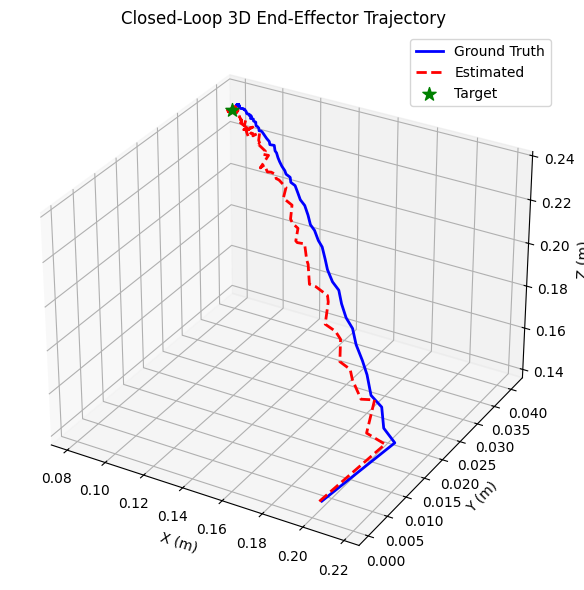

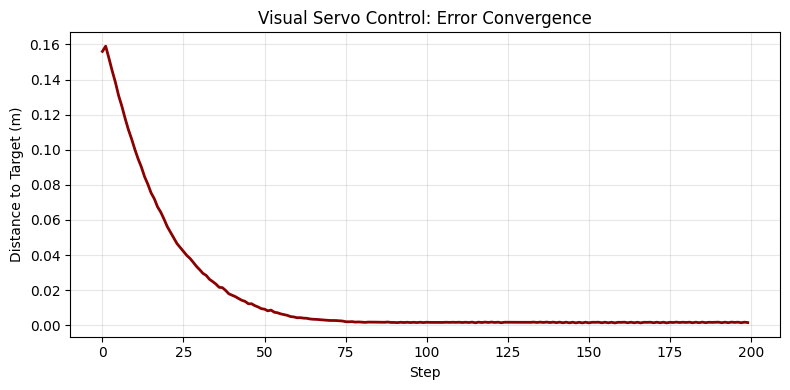

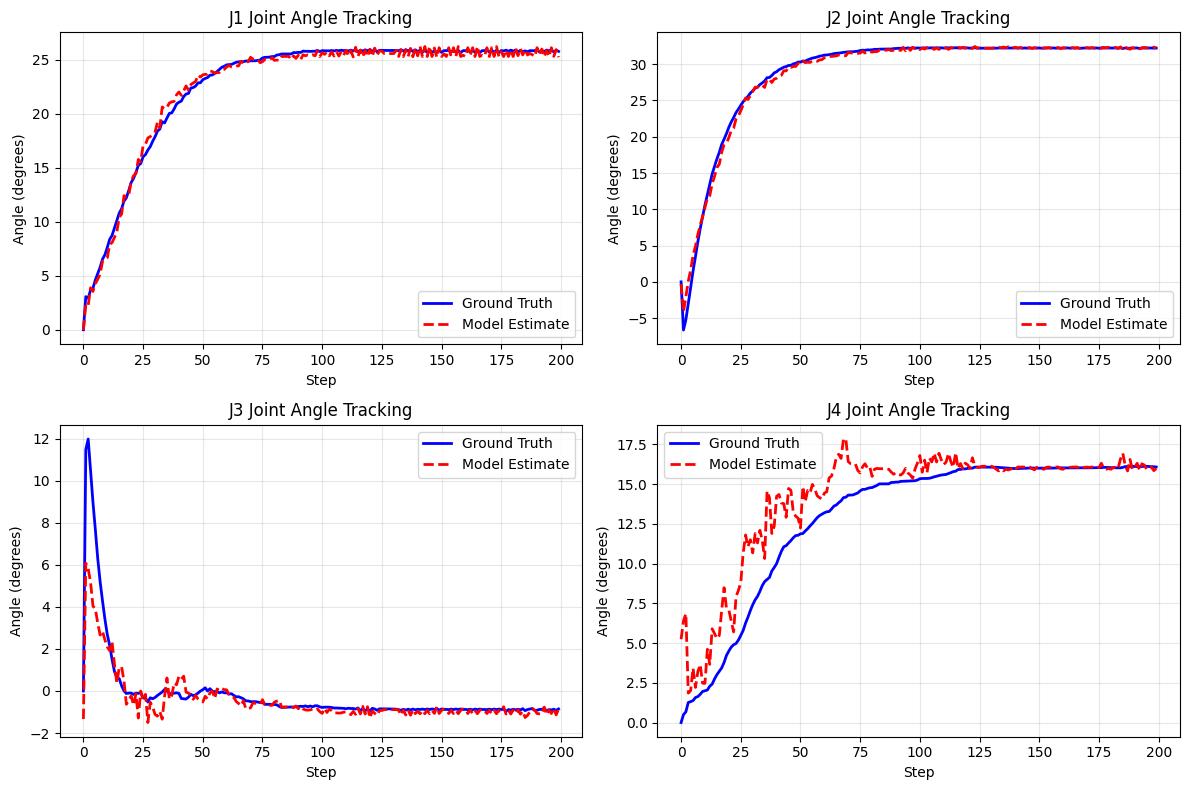

Final distance to target: 0.001563 m
Mean XYZ error: 0.002347 m
J1: mean=0.37°, median=0.34°, max=1.37°
J2: mean=0.32°, median=0.14°, max=3.15°
J3: mean=0.37°, median=0.17°, max=6.16°
J4: mean=1.22°, median=0.65°, max=6.18°


In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gt_xyz[:, 0], gt_xyz[:, 1], gt_xyz[:, 2], color='blue', linewidth=2, label='Ground Truth')
ax.plot(est_xyz[:, 0], est_xyz[:, 1], est_xyz[:, 2], color='red', linestyle='--', linewidth=2, label='Estimated')
ax.scatter(target_xyz_log[0, 0], target_xyz_log[0, 1], target_xyz_log[0, 2], c='green', s=100, marker='*', label='Target')
ax.set_title('Closed-Loop 3D End-Effector Trajectory')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(err_log, color='darkred', linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel('Distance to Target (m)')
ax.set_title('Visual Servo Control: Error Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, (ax, name) in enumerate(zip(axes.flat, ['J1', 'J2', 'J3', 'J4'])):
    ax.plot(gt_joint_angles[:, idx], color='blue', linewidth=2, label='Ground Truth')
    ax.plot(est_joint_angles[:, idx], color='red', linestyle='--', linewidth=2, label='Model Estimate')
    ax.set_title(f'{name} Joint Angle Tracking')
    ax.set_xlabel('Step')
    ax.set_ylabel('Angle (degrees)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

xyz_err = np.linalg.norm(est_xyz - gt_xyz, axis=1)
joint_err = np.abs(est_joint_angles - gt_joint_angles)
print(f'Final distance to target: {err_log[-1]:.6f} m')
print(f'Mean XYZ error: {xyz_err.mean():.6f} m')
for idx, name in enumerate(['J1', 'J2', 'J3', 'J4']):
    err = joint_err[:, idx]
    print(f'{name}: mean={err.mean():.2f}°, median={np.median(err):.2f}°, max={err.max():.2f}°')